# ODMR Analysis



<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Import Libraries</h2>
</div>

In [16]:
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
from lmfit.models import LorentzianModel, PolynomialModel
from scipy.signal import find_peaks
#import ipywidgets as widgets
from IPython.display import display, clear_output

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;"> General Helpful Functions</h2>
</div>

In [17]:
def load_run(run_folder):
    data = np.load(run_folder / "odmr_data.npz")
    with open(run_folder / "metadata.json") as f:
        metadata = json.load(f)

    # drop fields we don't need to carry around
    skip_keys = {"experiment_id", "timestamp"}
    run = {k: v for k, v in metadata.items() if k not in skip_keys}

    run["frequencies"] = data["frequencies"]
    run["signal"] = data["signal"]
    run["reference"] = data["reference"]
    run["contrast"] = data["contrast"]
    run["run_folder"] = run_folder

    return run


def load_all_runs(parent_dir):
    parent_dir = Path(parent_dir)
    runs = {}
    for run_folder in sorted(parent_dir.iterdir()):
        if not run_folder.is_dir():
            continue
        run_number = int(run_folder.name.split("_")[-1])
        runs[run_number] = load_run(run_folder)
    return runs

def plot_normalized_runs(runs, run_numbers, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    for run_number in run_numbers:
        run = runs[run_number]
        normalized_signal = run["signal"] / np.max(run["signal"])
        ax.plot(run["frequencies"], normalized_signal, label=f"run {run_number}")

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Normalized signal")
    ax.legend()
    return ax

def plot_raw_runs(runs, run_numbers, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    for run_number in run_numbers:
        run = runs[run_number]
        ax.plot(run["frequencies"], run["signal"], label=f"run {run_number}")

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Signal (counts per second)")
    ax.legend()
    return ax

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Load Data</h2>
</div>

In [28]:
parent_dir = "Z:\Data\DefectMsmts\Data\Albania\ODMR\Field_Sweep"
runs = load_all_runs(parent_dir)

print(list(runs.keys()))

[3, 70, 76, 78, 80, 81, 83]


In [7]:
print(runs[18].keys())

runs[22]["reps"]
runs[22]["laser_power"]
runs[18]["thickness"]

dict_keys(['laser_power', 'mw_gain', 'reps', 'ND Filter OD', 'relax_delay_treg', 'sweep_start_fGHz', 'sweep_stop_fGHz', 'sweep_step_fGHz', 'picture', 'thickness', 'frequencies', 'signal', 'reference', 'contrast', 'run_folder'])


'flake directly on waveguide'

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Raw Data</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Plot Raw Data</h3>
</div>


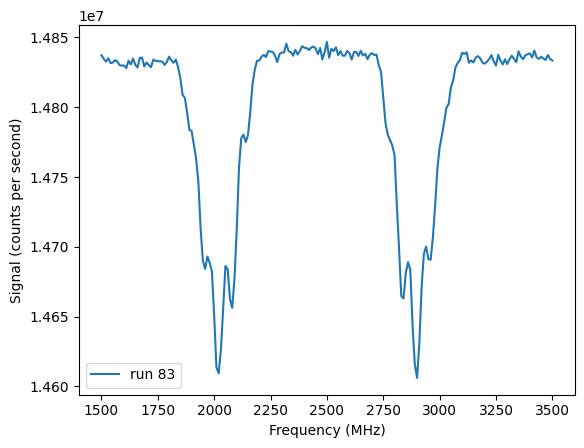

In [29]:

plot_raw_runs(runs, [83])
plt.show()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Normalized Plots</h3>
</div>


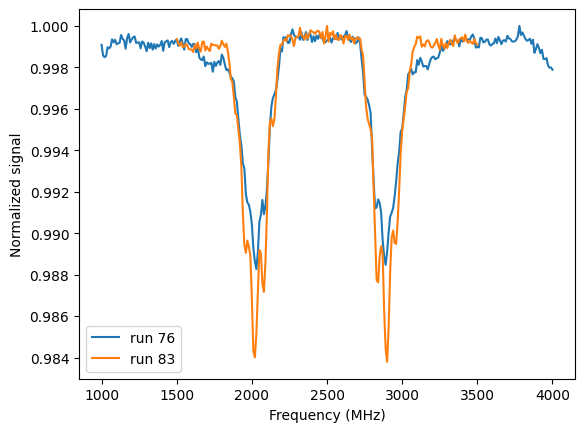

In [32]:
runs_1 = [3, 70, 76, 78, 80, 81,83]
runs_2 = [76,83]
plot_normalized_runs(runs, runs_2)
plt.show()

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Analysis</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Fit Functions</h3>
</div>


In [33]:
def find_dip_centers(run, n_peaks=4, prominence=None, freq_range=None):
    """
    (same docstring as before, plus:)

    freq_range (tuple of float or None): optional (min_freq, max_freq)
        to restrict the search window, excluding known artifact
        regions outside the real resonance range.
    """
    frequencies = run["frequencies"]
    signal = run["signal"]

    if freq_range is not None:
        mask = (frequencies >= freq_range[0]) & (frequencies <= freq_range[1])
        frequencies = frequencies[mask]
        signal = signal[mask]

    inverted = -signal
    peak_indices, properties = find_peaks(inverted, prominence=prominence)

    if prominence is None:
        peak_indices, properties = find_peaks(inverted, prominence=1)

    prominences = properties["prominences"]
    top_idx = np.argsort(prominences)[::-1][:n_peaks]
    top_peak_indices = peak_indices[top_idx]

    centers = frequencies[top_peak_indices]
    return np.sort(centers)

def build_odmr_model(centers, signal, sigma_guess=15):

    """
    Build a composite lmfit model for an ODMR spectrum: a polynomial
    baseline plus one Lorentzian dip per given center frequency.

    How it works:
    - Starts with a 3rd-degree polynomial to represent the baseline
    (the smooth background the dips sit on top of).
    - Adds one LorentzianModel per entry in `centers`, each with its
    own labeled prefix (l1_, l2_, l3_, ...) so parameters can be
    referenced by name later (e.g. result.params["l1_center"]).
    - Each Lorentzian's center is bounded to within +/-15 of its guess,
    sigma (width) is bounded between 1 and 60, and amplitude is
    constrained negative so it fits as a dip rather than a peak.

    Parameters:
        centers (list of float): initial guess frequencies for each
            dip center, typically from find_dip_centers().
        signal (np.ndarray): the ODMR signal data, used to set a realistic
            starting value for the baseline constant term.
        sigma_guess (float): initial guess for each dip's width
            (default 15).

    Returns:
        model (lmfit.Model): the combined baseline + Lorentzians model.
        params (lmfit.Parameters): initial parameter guesses and bounds
            for the model, ready to be passed into model.fit().
    """

    model = PolynomialModel(degree=3, prefix="bkg_")
    params = model.make_params()

    # give the constant term a realistic starting value instead of 0
    params["bkg_c0"].set(value=np.median(signal))
    params["bkg_c1"].set(value=0)
    params["bkg_c2"].set(value=0)
    params["bkg_c3"].set(value=0)

    for i, center in enumerate(centers, start=1):
        prefix = f"l{i}_"
        lz = LorentzianModel(prefix=prefix)
        model = model + lz
        lz_params = lz.make_params()
        lz_params[f"{prefix}center"].set(value=center, min=center-15, max=center+15)
        lz_params[f"{prefix}sigma"].set(value=sigma_guess, min=1, max=60)
        lz_params[f"{prefix}amplitude"].set(value=-1e7, min=-1e9, max=0)
        params.update(lz_params)

    return model, params

def fit_run(run, centers):

    """
    Fit a single run's ODMR signal to the baseline + Lorentzians model.

    How it works:
    - Builds the model and initial parameters via build_odmr_model()
    using the given center guesses.
    - Fits that model to the run's raw signal as a function of frequency
    using lmfit's least-squares fitting.

    Parameters:
        run (dict): a single run's data dictionary, must contain
            "frequencies" and "signal" arrays.
        centers (list of float): initial guess frequencies for each
            dip center, typically from find_dip_centers().

    Returns:
        result (lmfit.ModelResult): the fit result object, containing
            fitted parameters, uncertainties, and fit diagnostics
            (access via result.fit_report(), result.params, etc.).
    """

    model, params = build_odmr_model(centers,run["signal"])
    result = model.fit(run["signal"], params, x=run["frequencies"])
    return result

def compute_contrast(result, frequencies, n_peaks=4):

    """
    Compute ODMR contrast from a fit result, defined as the average of
    the two deepest Lorentzian dips (each dip depth normalized by the
    local baseline value at that dip's center).

    How it works:
    - For each fitted Lorentzian, pulls its center and dip depth
    (height), then finds the baseline's fitted value at that same
    center frequency.
    - Normalizes each dip's depth by its local baseline value, giving
    a fractional contrast per line.
    - Sorts all dip contrasts and averages the two largest, since the
    two most prominent dips dominate the visible signal and averaging
    them improves SNR by a factor of sqrt(2) over using just one.

    Parameters:
        result (lmfit.ModelResult): fit result from fit_run().
        frequencies (np.ndarray): frequency array for the run (used to
            look up the baseline value nearest each dip's center).
        n_peaks (int): number of Lorentzians in the fit (default 4).

    Returns:
        contrast (float): average fractional contrast of the two
            deepest dips.
        depths (list of float): fractional contrast for all n_peaks
            dips, sorted largest to smallest.
    """

    depths = []
    centers = []
    for i in range(1, n_peaks + 1):
        prefix = f"l{i}_"
        center = result.params[f"{prefix}center"].value
        height = abs(result.params[f"{prefix}height"].value)
        baseline_val = result.eval_components()["bkg_"][np.argmin(np.abs(frequencies - center))]
        depths.append(height / baseline_val)
        centers.append(center)

    # contrast still uses the two deepest, regardless of order
    contrast = np.mean(sorted(depths, reverse=True)[:2])

    # but for display, sort everything by frequency (left to right)
    order = np.argsort(centers)
    centers = [centers[i] for i in order]
    depths = [depths[i] for i in order]

    return contrast, depths, centers

def plot_normalized_fits(runs, run_numbers, ax=None, freq_ranges=None):
    if ax is None:
        fig, ax = plt.subplots()

    freq_ranges = freq_ranges or {}
    info_lines = []

    for run_number in run_numbers:
        run = runs[run_number]
        freq_range = freq_ranges.get(run_number)
        centers = find_dip_centers(run, n_peaks=4, freq_range=freq_range)
        result = fit_run(run, centers)
        contrast, depths, dip_centers = compute_contrast(result, run["frequencies"])

        norm = np.max(run["signal"])
        line, = ax.plot(run["frequencies"], run["signal"] / norm, label=f"run {run_number}")
        ax.plot(run["frequencies"], result.best_fit / norm, linestyle="--",
                color=line.get_color(), alpha=0.5, linewidth=1)

        info_lines.append(f"run {run_number}: contrast (avg top 2) = {contrast:.4f}")

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Normalized signal")
    ax.legend()

    info_text = "\n".join(info_lines)
    fig = ax.get_figure()
    fig.text(1.02, 0.5, info_text, transform=ax.transAxes, va="center", ha="left", fontsize=10)
    plt.tight_layout()

    return ax

def plot_contrast_vs_run(runs, run_numbers, ax=None, freq_ranges=None):
    """
    (same docstring as before)
    """
    if ax is None:
        fig, ax = plt.subplots()

    freq_ranges = freq_ranges or {}
    contrasts = []
    for run_number in run_numbers:
        run = runs[run_number]
        freq_range = freq_ranges.get(run_number)
        centers = find_dip_centers(run, n_peaks=4, freq_range=freq_range)
        result = fit_run(run, centers)
        contrast, depths, dip_centers = compute_contrast(result, run["frequencies"])
        contrasts.append(contrast)

    bars = ax.bar([str(r) for r in run_numbers], contrasts)

    for bar, contrast in zip(bars, contrasts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{contrast:.4f}", ha="center", va="bottom", fontsize=9)

    ax.set_xlabel("Run number")
    ax.set_ylabel("Contrast (avg of top 2 dips)")
    ax.set_title("Contrast vs. run number")

    return ax

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Find Dips</h3>
</div>


[1959.99998245 2019.99998016 2079.99997787 2139.99997559]


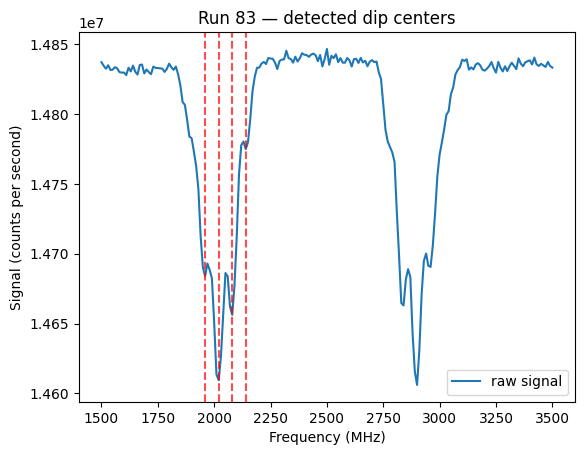

In [37]:
run_num = 83
centers = find_dip_centers(runs[run_num], n_peaks=4, freq_range=(1750, 2250))
print(centers)

fig, ax = plt.subplots()
ax.plot(runs[run_num]["frequencies"], runs[run_num]["signal"], label="raw signal")

for c in centers:
    ax.axvline(c, color="red", linestyle="--", alpha=0.7)

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (counts per second)")
ax.set_title(f"Run {run_num} — detected dip centers")
ax.legend()
plt.show()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Lorentzian Fit</h3>
</div>


/Users/jereemurray/opt/anaconda3/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


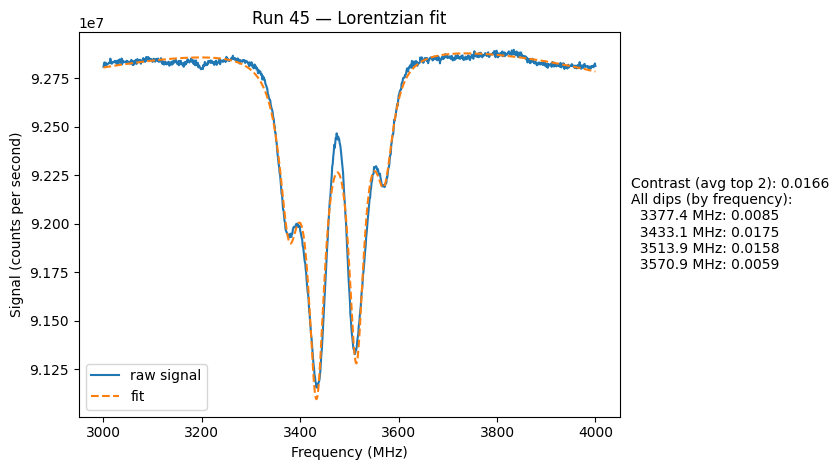

In [12]:
result = fit_run(runs[run_num], centers)
contrast, depths, centers = compute_contrast(result, runs[run_num]["frequencies"])

fig, ax = plt.subplots()
ax.plot(runs[run_num]["frequencies"], runs[run_num]["signal"], label="raw signal")
ax.plot(runs[run_num]["frequencies"], result.best_fit, label="fit", linestyle="--")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (counts per second)")
ax.set_title(f"Run {run_num} — Lorentzian fit")
ax.legend()

contrast, depths, centers = compute_contrast(result, runs[run_num]["frequencies"])

info_text = f"Contrast (avg top 2): {contrast:.4f}\nAll dips (by frequency):\n"
info_text += "\n".join(f"  {c:.1f} MHz: {d:.4f}" for c, d in zip(centers, depths))

fig.text(1.02, 0.5, info_text, transform=ax.transAxes, va="center", ha="left", fontsize=10)

plt.tight_layout()
plt.show()

Save Plot

In [13]:
save_path = runs[run_num]["run_folder"] / "lorentzian_fit.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to {save_path}")

Saved to /Volumes/hlab-nas/Data/DefectMsmts/Data/Albania/ODMR_Pub_Data/20260910062303_045/lorentzian_fit.png


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Multiple</h3>
</div>


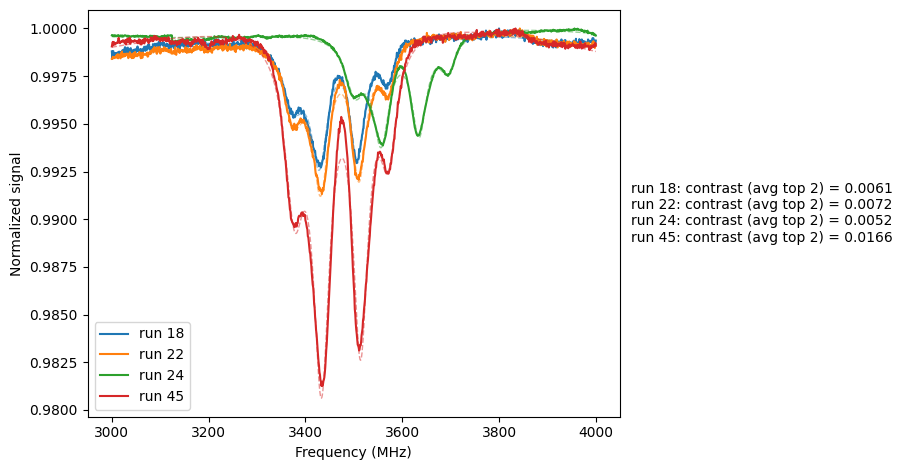

In [14]:
plot_normalized_fits(runs, [18, 22, 24,45], freq_ranges={24: (3400, 3800)})
plt.show()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Comparisons</h3>
</div>


<Axes: title={'center': 'Contrast vs. run number'}, xlabel='Run number', ylabel='Contrast (avg of top 2 dips)'>

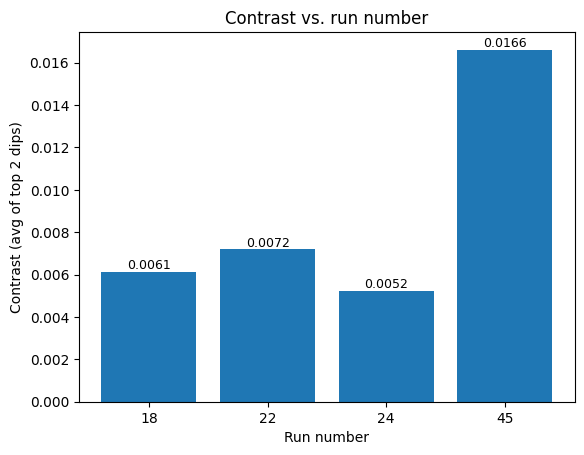

In [15]:
plot_contrast_vs_run(runs, [18, 22, 24,45], freq_ranges={24: (3400, 3800)})

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Interactive</h2>
</div>

In [30]:
def build_tuning_app(runs, run_numbers, freq_ranges=None):
    """
    Side-by-side tuning view: one panel per run, each showing raw
    signal + fit + per-peak contrast, with its own frequency-range
    slider that updates the fit live.

    freq_ranges (dict or None): existing {run_number: (min, max)}
        ranges to start from; updated in place as you adjust sliders,
        so you can pass this same dict into Stage 2 afterward.

    Returns the freq_ranges dict (same object being updated live).
    """
    freq_ranges = freq_ranges if freq_ranges is not None else {}
    sliders = {}
    slider_widgets = []

    for run_number in run_numbers:
        run = runs[run_number]
        fmin, fmax = float(run["frequencies"].min()), float(run["frequencies"].max())
        default_range = freq_ranges.get(run_number, (fmin, fmax))
        slider = widgets.FloatRangeSlider(
            value=default_range, min=fmin, max=fmax, step=1,
            description=f"Run {run_number}:",
            layout=widgets.Layout(width="320px"),
            style={"description_width": "initial"}
        )
        sliders[run_number] = slider
        slider_widgets.append(slider)

    output = widgets.Output()

    def redraw(change=None):
        with output:
            clear_output(wait=True)
            n = len(run_numbers)
            fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
            if n == 1:
                axes = [axes]

            for ax, run_number in zip(axes, run_numbers):
                run = runs[run_number]
                freq_range = tuple(sliders[run_number].value)
                freq_ranges[run_number] = freq_range

                ax.plot(run["frequencies"], run["signal"], label="raw", linewidth=1)

                try:
                    centers = find_dip_centers(run, n_peaks=4, freq_range=freq_range)
                    result = fit_run(run, centers)
                    contrast, depths, dip_centers = compute_contrast(result, run["frequencies"])
                    ax.plot(run["frequencies"], result.best_fit, linestyle="--", alpha=0.7, label="fit")
                    info = f"contrast: {contrast:.4f}\n" + "\n".join(
                        f"{c:.0f} MHz: {d:.4f}" for c, d in zip(dip_centers, depths)
                    )
                except Exception:
                    info = "fit failed\n(adjust range)"

                ax.axvline(freq_range[0], color="red", linestyle="--", alpha=0.5)
                ax.axvline(freq_range[1], color="red", linestyle="--", alpha=0.5)
                ax.set_title(f"Run {run_number}")
                ax.set_xlabel("Frequency (MHz)")
                ax.set_ylabel("Signal")
                ax.legend(fontsize=8)
                ax.text(0.98, 0.02, info, transform=ax.transAxes, fontsize=8, va="bottom", ha="right")

            plt.tight_layout()
            plt.show()

    for slider in slider_widgets:
        slider.observe(redraw, names="value")

    display(widgets.HBox(slider_widgets))
    display(output)
    redraw()

    return freq_ranges

In [31]:
freq_ranges = build_tuning_app(runs, [18, 22, 24])

Output()

In [ ]:
overlay_run_selector = widgets.SelectMultiple(
    options=sorted(runs.keys()),
    description="Runs:",
    rows=6
)
overlay_plot_button = widgets.Button(description="Plot normalized overlay")
overlay_output = widgets.Output()

def on_overlay_plot_clicked(b):
    with overlay_output:
        clear_output(wait=True)
        selected_runs = list(overlay_run_selector.value)
        if not selected_runs:
            print("Select at least one run first.")
            return
        plot_normalized_fits(runs, selected_runs, freq_ranges=freq_ranges)
        plt.show()

overlay_plot_button.on_click(on_overlay_plot_clicked)

display(overlay_run_selector, overlay_plot_button, overlay_output)

SelectMultiple(description='Runs:', options=(18, 22, 24), rows=6, value=())

Button(description='Plot normalized overlay', style=ButtonStyle())

Output()